# A/B Testing Real - Udacity Experiment Analysis

## Introducción

Bienvenido a **FASE APLICADA 2**: A/B Testing con un dataset **real y limpio** de Udacity.

### Contexto del Experimento

Udacity ejecutó un experimento A/B para validar si una **nueva landing page** mejora las conversiones.

**Preguntas críticas:**
> - ¿La nueva página convierte MEJOR que la antigua?
> - ¿Es estadísticamente significativo?
> - ¿Funciona igual para TODOS los usuarios o hay segmentos?
> - ¿DEBEMOS LANZAR la nueva página?

### Dataset

- **Fuente**: Udacity A/B Testing Course
- **Tamaño**: ~294,000 usuarios
- **Métrica**: Conversion Rate (conversión sí/no)
- **Grupos**: Control (old page) vs Treatment (new page)

### Objetivo de esta Notebook

1. ✓ Cargar y explorar datos reales
2. ✓ Limpiar inconsistencias
3. ✓ Análisis global (control vs treatment)
4. ✓ Validación estadística (t-test)
5. ✓ Análisis de segmentos (por hora, por página)
6. ✓ Visualizaciones claras
7. ✓ **Decisión de negocio: ¿Lanzar o no?**

## PASO 1: Cargar Dataset

### Objetivo
Cargar el archivo CSV de Udacity y explorar su estructura básica.

### Dataset Structure
Esperamos 5 columnas principales:
- `user_id`: Identificador único del usuario
- `timestamp`: Cuándo visitó el usuario
- `group`: Control (old_page) o Treatment (new_page)
- `landing_page`: Qué página vio (old_page o new_page)
- `converted`: Si convirtió (0=no, 1=sí)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
path = '../data/ab_data.csv'
df = pd.read_csv(path)

print(f"✓ Dataset cargado: {len(df):,} filas, {len(df.columns)} columnas")
print()
print("Primeras 5 filas:")
print(df.head())
print()
print("Columnas:")
print(df.columns.tolist())

✓ Dataset cargado: 294,478 filas, 5 columnas

Primeras 5 filas:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Columnas:
['user_id', 'timestamp', 'group', 'landing_page', 'converted']


## PASO 2: Exploración Inicial

### Qué Vamos a Explorar

1. **Tipos de datos** → Validar estructura
2. **Distribución de grupos** → ¿Cuántos en control vs treatment?
3. **Tasa de conversión global** → Baseline
4. **Valores faltantes** → ¿Hay datos incompletos?

### Conceptos Clave

- **Control**: Usuarios que ven la página ANTIGUA (baseline)
- **Treatment**: Usuarios que ven la página NUEVA (experimental)
- **Conversión**: Usuario completó la acción deseada (compra, signup, etc.)
- **Conversion Rate**: % de usuarios que convirtieron

In [3]:
# Exploración básica
print("="*70)
print("EXPLORACIÓN DEL DATASET")
print("="*70)
print()

# Tipos y estructura
print("INFORMACIÓN DEL DATASET:")
print(df.info())
print()

# Distribución de grupos
print("-"*70)
print("DISTRIBUCIÓN DE GRUPOS:")
print(df["group"].value_counts())
print()
print("Porcentaje:")
print(df["group"].value_counts(normalize=True) * 100)
print()

# Conversión global
print("-"*70)
print("CONVERSIÓN GLOBAL:")
conversion_rate = df["converted"].mean()
print(f"Tasa de conversión general: {conversion_rate:.2%}")
print(f"Total conversiones: {df['converted'].sum():,}")
print(f"Total no-conversiones: {(df['converted'] == 0).sum():,}")
print()

# Valores faltantes
print("-"*70)
print("VALORES FALTANTES:")
print(df.isnull().sum())
print()
print("="*70)

EXPLORACIÓN DEL DATASET

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None

----------------------------------------------------------------------
DISTRIBUCIÓN DE GRUPOS:
group
treatment    147276
control      147202
Name: count, dtype: int64

Porcentaje:
group
treatment    50.012565
control      49.987435
Name: proportion, dtype: float64

----------------------------------------------------------------------
CONVERSIÓN GLOBAL:
Tasa de conversión general: 11.97%
Total conversiones: 35,237
Total no-conversiones: 259,241

--------------------------------

## PASO 3: Limpieza y Validación

### ¿Por Qué Limpiar?

A veces en experimentos A/B hay **inconsistencias**:
- Un usuario en grupo 'treatment' pero vio old_page
- Un usuario en grupo 'control' pero vio new_page

Esto sucede por:
- Errores de implementación
- Usuarios que viajan entre regiones
- Bugs en el servidor

### Validación Correcta

Eliminamos filas donde:
- `group == 'treatment'` PERO `landing_page == 'old_page'` ❌
- `group == 'control'` PERO `landing_page == 'new_page'` ❌

Mantenemos solo:
- `group == 'treatment'` Y `landing_page == 'new_page'` ✓
- `group == 'control'` Y `landing_page == 'old_page'` ✓

In [4]:
# Verificar inconsistencias
print("="*70)
print("VALIDACIÓN DE DATOS")
print("="*70)
print()

# Antes de limpiar
rows_antes = len(df)
print(f"Filas ANTES de limpiar: {rows_antes:,}")
print()

# Contar inconsistencias
treatment_wrong = ((df["group"] == "treatment") & (df["landing_page"] == "old_page")).sum()
control_wrong = ((df["group"] == "control") & (df["landing_page"] == "new_page")).sum()

print(f"Inconsistencias encontradas:")
print(f"  • Treatment pero vio old_page: {treatment_wrong:,}")
print(f"  • Control pero vio new_page: {control_wrong:,}")
total_inconsistencias = treatment_wrong + control_wrong
print(f"  • Total a eliminar: {total_inconsistencias:,}")
print()

# Limpiar datos
df = df[
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page")) |
    ((df["group"] == "control") & (df["landing_page"] == "old_page"))
]

rows_despues = len(df)
print(f"Filas DESPUÉS de limpiar: {rows_despues:,}")
print(f"Filas eliminadas: {rows_antes - rows_despues:,}")
print()
print(f"✓ Dataset limpio y listo para análisis")
print("="*70)

VALIDACIÓN DE DATOS

Filas ANTES de limpiar: 294,478

Inconsistencias encontradas:
  • Treatment pero vio old_page: 1,965
  • Control pero vio new_page: 1,928
  • Total a eliminar: 3,893

Filas DESPUÉS de limpiar: 290,585
Filas eliminadas: 3,893

✓ Dataset limpio y listo para análisis


## PASO 4: Crear Variables Clave

### Variables Derivadas

Creamos variables que facilitan el análisis:

- **`treatment`** (0/1): 0 = Control (old_page), 1 = Treatment (new_page)
- **`conversion`** (0/1): 0 = No convirtió, 1 = Convirtió

### Por Qué Esto Importa

Las variables binarias (0/1) permiten:
- Cálculos estadísticos directos
- Comparaciones más simples
- Código más limpio y reutilizable

In [5]:
# Crear variables clave
df["treatment"] = (df["group"] == "treatment").astype(int)
df["conversion"] = df["converted"].astype(int)

print("Variables derivadas creadas:")
print()
print(f"treatment:")
print(df["treatment"].value_counts().sort_index())
print()
print(f"conversion:")
print(df["conversion"].value_counts().sort_index())
print()

# Verificar la nueva estructura
print("Muestra del dataset procesado:")
print(df[["user_id", "group", "treatment", "converted", "conversion"]].head(10))

Variables derivadas creadas:

treatment:
treatment
0    145274
1    145311
Name: count, dtype: int64

conversion:
conversion
0    255832
1     34753
Name: count, dtype: int64

Muestra del dataset procesado:
   user_id      group  treatment  converted  conversion
0   851104    control          0          0           0
1   804228    control          0          0           0
2   661590  treatment          1          0           0
3   853541  treatment          1          0           0
4   864975    control          0          1           1
5   936923    control          0          0           0
6   679687  treatment          1          1           1
7   719014    control          0          0           0
8   817355  treatment          1          1           1
9   839785  treatment          1          1           1


## PASO 5: Análisis Global

### Pregunta Central

> "En promedio, ¿la nueva página (treatment) convierte MEJOR que la antigua (control)?"

### Métrica: Uplift

$$\text{Uplift} = \text{Conversion Rate}_{treatment} - \text{Conversion Rate}_{control}$$

- Si Uplift > 0: Treatment es mejor ✓
- Si Uplift < 0: Control es mejor ✗
- Si Uplift ≈ 0: Son prácticamente iguales =

### Función Reutilizable

Crearemos una función que nos permita:
1. Separar datos por grupo
2. Calcular métricas de cada grupo
3. Comparar resultados

In [6]:
# Función reutilizable para A/B test
def run_ab_test(df, group_col, metric_col):
    """
    Ejecuta un análisis A/B comparando dos grupos.
    
    Parámetros:
    - df: DataFrame con los datos
    - group_col: Nombre de columna con grupos (0/1)
    - metric_col: Nombre de columna con métrica a comparar (0/1)
    
    Retorna:
    - dict con control_mean, treatment_mean, uplift
    """
    control = df[df[group_col] == 0][metric_col]
    treatment = df[df[group_col] == 1][metric_col]
    
    control_mean = control.mean()
    treatment_mean = treatment.mean()
    uplift = treatment_mean - control_mean
    uplift_pct = (uplift / control_mean) * 100 if control_mean > 0 else 0
    
    return {
        "control_mean": control_mean,
        "treatment_mean": treatment_mean,
        "uplift": uplift,
        "uplift_pct": uplift_pct,
        "control_n": len(control),
        "treatment_n": len(treatment)
    }


# Ejecutar análisis global
print("="*70)
print("ANÁLISIS GLOBAL: CONTROL vs TREATMENT")
print("="*70)
print()

results = run_ab_test(df, "treatment", "conversion")

print(f"CONTROL (Old Page):")
print(f"  • Usuarios: {results['control_n']:,}")
print(f"  • Conversion Rate: {results['control_mean']:.2%}")
print()
print(f"TREATMENT (New Page):")
print(f"  • Usuarios: {results['treatment_n']:,}")
print(f"  • Conversion Rate: {results['treatment_mean']:.2%}")
print()
print(f"DIFERENCIA (Uplift):")
print(f"  • Absoluto: {results['uplift']:.4f} ({results['uplift']:.2%})")
print(f"  • Relativo: {results['uplift_pct']:+.2f}%")
print()

# Interpretación simple
if results['uplift'] > 0:
    print(f"✓ La NEW PAGE convierte MEJOR")
elif results['uplift'] < 0:
    print(f"✗ La OLD PAGE convierte MEJOR")
else:
    print(f"= Ambas páginas convierten IGUAL")
    
print()
print("⚠️ NOTA: Esto es solo un promedio. Debemos validar si es SIGNIFICATIVO.")
print("="*70)

ANÁLISIS GLOBAL: CONTROL vs TREATMENT

CONTROL (Old Page):
  • Usuarios: 145,274
  • Conversion Rate: 12.04%

TREATMENT (New Page):
  • Usuarios: 145,311
  • Conversion Rate: 11.88%

DIFERENCIA (Uplift):
  • Absoluto: -0.0016 (-0.16%)
  • Relativo: -1.31%

✗ La OLD PAGE convierte MEJOR

⚠️ NOTA: Esto es solo un promedio. Debemos validar si es SIGNIFICATIVO.


## PASO 6: Validación Estadística (T-Test)

### ¿Por Qué T-Test?

El uplift que vimos (Paso 5) es real en los **datos que tenemos**.

Pero pregunta más importante:
> **¿Este uplift es genuino o podría ser suerte/azar?**

### Qué Hace el T-Test

1. Compara las dos distribuciones (control vs treatment)
2. Calcula un **t-statistic** (medida de diferencia)
3. Produce un **p-value** (probabilidad de que sea por azar)

### Interpretación del P-Value

- **p-value < 0.05**: Resultado SIGNIFICATIVO (solo 5% chance de azar) ✓
- **p-value ≥ 0.05**: Resultado NO significativo (>5% chance de azar) ✗

Si resultado es significativo → Podemos confiar en el uplift
Si NO es significativo → Podría ser suerte, no lanzar

In [7]:
# T-Test
print("="*70)
print("VALIDACIÓN ESTADÍSTICA: T-TEST")
print("="*70)
print()

# Extraer datos
control_conversions = df[df["treatment"] == 0]["conversion"]
treatment_conversions = df[df["treatment"] == 1]["conversion"]

# Ejecutar t-test
t_stat, p_value = stats.ttest_ind(treatment_conversions, control_conversions)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")
print()

# Interpretación
alpha = 0.05
print(f"Nivel de significancia (α): {alpha}")
print()

if p_value < alpha:
    print(f"✓ SIGNIFICATIVO: p-value ({p_value:.6f}) < α ({alpha})")
    print(f"  → La diferencia es REAL (solo {p_value*100:.2f}% de chance de azar)")
    significant = True
else:
    print(f"✗ NO SIGNIFICATIVO: p-value ({p_value:.6f}) ≥ α ({alpha})")
    print(f"  → La diferencia podría ser suerte ({p_value*100:.2f}% de chance de azar)")
    significant = False

print()
print("="*70)
print()

# Conclusión simple
if significant:
    if results['uplift'] > 0:
        print("🟢 CONCLUSIÓN: Nueva página MEJORA significativamente las conversiones")
    else:
        print("🔴 CONCLUSIÓN: Nueva página EMPEORA significativamente las conversiones")
else:
    print("🟡 CONCLUSIÓN: No hay diferencia estadísticamente significativa")

VALIDACIÓN ESTADÍSTICA: T-TEST

T-Statistic: -1.3116
P-Value: 0.189654

Nivel de significancia (α): 0.05

✗ NO SIGNIFICATIVO: p-value (0.189654) ≥ α (0.05)
  → La diferencia podría ser suerte (18.97% de chance de azar)


🟡 CONCLUSIÓN: No hay diferencia estadísticamente significativa


## PASO 7: Crear Segmentos

### ¿Por Qué Segmentar?

A veces un tratamiento funciona bien **en promedio** pero:
- **Funciona MEJOR** en ciertos segmentos
- **Funciona PEOR** en otros segmentos
- Podríamos estar **ocultando oportunidades**

### Dos Segmentaciones

#### 1. Por Hora del Día
**Pregunta**: ¿El tratamiento funciona igual de día y de noche?
- Usuarios matutinos (8am-8pm) = "day"
- Usuarios nocturnos (8pm-8am) = "night"

#### 2. Por Tipo de Página Landing
**Pregunta**: ¿El tratamiento interactúa con el tipo de página?
- old_page
- new_page

In [8]:
# Crear segmentos
print("="*70)
print("CREACIÓN DE SEGMENTOS")
print("="*70)
print()

# Segmento 1: Por hora del día
print("Segmento 1: Hora del Día")
print("-" * 70)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour

def categorize_time(hour):
    if 8 <= hour <= 20:
        return "day"
    else:
        return "night"

df["time_segment"] = df["hour"].apply(categorize_time)

print(f"Usuarios por segmento de tiempo:")
print(df["time_segment"].value_counts())
print()

# Segmento 2: Por tipo de página
print("-" * 70)
print("Segmento 2: Tipo de Página")
print("-" * 70)

df["page_segment"] = df["landing_page"]

print(f"Usuarios por tipo de página:")
print(df["page_segment"].value_counts())
print()

print("✓ Segmentos creados exitosamente")
print("="*70)

CREACIÓN DE SEGMENTOS

Segmento 1: Hora del Día
----------------------------------------------------------------------
Usuarios por segmento de tiempo:
time_segment
day      157442
night    133143
Name: count, dtype: int64

----------------------------------------------------------------------
Segmento 2: Tipo de Página
----------------------------------------------------------------------
Usuarios por tipo de página:
page_segment
new_page    145311
old_page    145274
Name: count, dtype: int64

✓ Segmentos creados exitosamente


## PASO 8: Análisis por Segmentos

### Conversión por Cada Segmento

Analizaremos cómo varía la conversión en:
1. Cada combinación de tiempo + grupo (día/control, día/treatment, noche/control, noche/treatment)
2. Cada tipo de página + grupo

### Buscamos

- ¿El treatment funciona igual en day y night?
- ¿El treatment funciona mejor en old_page o new_page?
- ¿Hay segmentos donde debería NO lanzar el treatment?

In [9]:
# Análisis por segmentos
print("="*70)
print("ANÁLISIS POR SEGMENTOS")
print("="*70)
print()

# Segmento 1: Por hora
print("SEGMENTO 1: POR HORA DEL DÍA")
print("-" * 70)

time_analysis = df.groupby(["time_segment", "treatment"])["conversion"].agg([
    ("conversion_rate", "mean"),
    ("count", "size")
]).round(4)

print(time_analysis)
print()

# Calcular uplift por segmento temporal
print("Uplift por segmento de tiempo:")
for time_seg in df["time_segment"].unique():
    seg_data = df[df["time_segment"] == time_seg]
    seg_results = run_ab_test(seg_data, "treatment", "conversion")
    print(f"  {time_seg.upper()}: Control={seg_results['control_mean']:.2%}, "
          f"Treatment={seg_results['treatment_mean']:.2%}, "
          f"Uplift={seg_results['uplift']:+.2%}")

print()
print("="*70)
print()

# Segmento 2: Por página
print("SEGMENTO 2: POR TIPO DE PÁGINA")
print("-" * 70)

page_analysis = df.groupby(["page_segment", "treatment"])["conversion"].agg([
    ("conversion_rate", "mean"),
    ("count", "size")
]).round(4)

print(page_analysis)
print()

# Calcular uplift por segmento de página
print("Uplift por tipo de página:")
for page_seg in df["page_segment"].unique():
    seg_data = df[df["page_segment"] == page_seg]
    seg_results = run_ab_test(seg_data, "treatment", "conversion")
    print(f"  {page_seg.upper()}: Control={seg_results['control_mean']:.2%}, "
          f"Treatment={seg_results['treatment_mean']:.2%}, "
          f"Uplift={seg_results['uplift']:+.2%}")

print()
print("="*70)

ANÁLISIS POR SEGMENTOS

SEGMENTO 1: POR HORA DEL DÍA
----------------------------------------------------------------------
                        conversion_rate  count
time_segment treatment                        
day          0                   0.1206  78686
             1                   0.1209  78756
night        0                   0.1202  66588
             1                   0.1164  66555

Uplift por segmento de tiempo:
  NIGHT: Control=12.02%, Treatment=11.64%, Uplift=-0.38%
  DAY: Control=12.06%, Treatment=12.09%, Uplift=+0.03%


SEGMENTO 2: POR TIPO DE PÁGINA
----------------------------------------------------------------------
                        conversion_rate   count
page_segment treatment                         
new_page     1                   0.1188  145311
old_page     0                   0.1204  145274

Uplift por tipo de página:
  OLD_PAGE: Control=12.04%, Treatment=nan%, Uplift=+nan%
  NEW_PAGE: Control=nan%, Treatment=11.88%, Uplift=+nan%



## PASO 9: Visualización de Resultados

### Tres Gráficos Clave

1. **Control vs Treatment Global** → Muestra la diferencia general
2. **Por Hora del Día** → ¿El efecto es consistente?
3. **Por Tipo de Página** → ¿Hay interacciones?

Los gráficos nos ayudan a:
- Identificar rápidamente patrones
- Comunicar resultados al equipo ejecutivo
- Detectar segmentos problemáticos

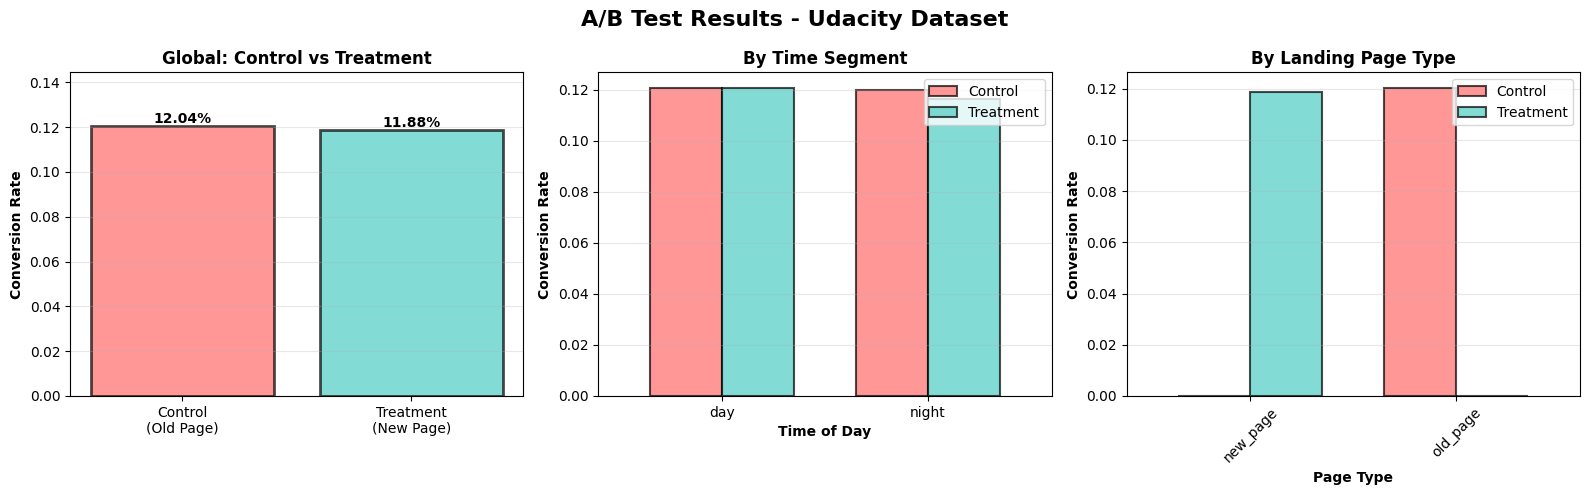

✓ Visualizaciones completadas


In [10]:
# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test Results - Udacity Dataset', fontsize=16, fontweight='bold')

# Gráfico 1: Control vs Treatment Global
ax1 = axes[0]
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
conversions = [
    df[df['treatment'] == 0]['conversion'].mean(),
    df[df['treatment'] == 1]['conversion'].mean()
]
colors = ['#FF6B6B', '#4ECDC4']
bars1 = ax1.bar(groups, conversions, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Conversion Rate', fontweight='bold')
ax1.set_title('Global: Control vs Treatment', fontweight='bold')
ax1.set_ylim([0, max(conversions) * 1.2])
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{conversions[i]:.2%}',
            ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Por Hora del Día
ax2 = axes[1]
time_data = df.groupby(['time_segment', 'treatment'])['conversion'].mean().unstack()
time_data.plot(kind='bar', ax=ax2, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, width=0.7)
ax2.set_ylabel('Conversion Rate', fontweight='bold')
ax2.set_xlabel('Time of Day', fontweight='bold')
ax2.set_title('By Time Segment', fontweight='bold')
ax2.legend(['Control', 'Treatment'], loc='best')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Por Tipo de Página
ax3 = axes[2]
page_data = df.groupby(['page_segment', 'treatment'])['conversion'].mean().unstack()
page_data.plot(kind='bar', ax=ax3, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, width=0.7)
ax3.set_ylabel('Conversion Rate', fontweight='bold')
ax3.set_xlabel('Page Type', fontweight='bold')
ax3.set_title('By Landing Page Type', fontweight='bold')
ax3.legend(['Control', 'Treatment'], loc='best')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones completadas")

## PASO 10: Análisis Profundo

### Preguntas a Responder

1. **¿El efecto es consistente?**
   - ¿Todos los segmentos muestran el mismo patrón?
   - ¿O hay variación sorprendente?

2. **¿Hay segmentos donde el tratamiento es PEOR?**
   - Si sí → No lanzar para esos segmentos
   - Si no → Podemos lanzar globalmente

3. **¿Hay oportunidades de optimización?**
   - ¿Dónde el tratamiento funciona mejor?
   - ¿Podemos mejorar aún más?

In [11]:
# Análisis profundo
print("="*70)
print("ANÁLISIS PROFUNDO DE SEGMENTOS")
print("="*70)
print()

# Pregunta 1: ¿Consistencia del efecto?
print("1️⃣  ¿EL EFECTO ES CONSISTENTE?")
print("-" * 70)

uplift_by_time = {}
for time_seg in sorted(df["time_segment"].unique()):
    seg_data = df[df["time_segment"] == time_seg]
    seg_results = run_ab_test(seg_data, "treatment", "conversion")
    uplift_by_time[time_seg] = seg_results['uplift']

print("\nUplift por segmento temporal:")
for seg, uplift in uplift_by_time.items():
    direction = "↑" if uplift > 0 else "↓"
    print(f"  {direction} {seg.upper():6s}: {uplift:+.4f} ({uplift:+.2%})")

# Análisis de consistencia
uplift_values = list(uplift_by_time.values())
uplift_std = np.std(uplift_values)
print(f"\nConsistencia (Std Dev of uplifts): {uplift_std:.4f}")

if uplift_std < 0.01:
    print("✓ MUY CONSISTENTE: El efecto es similar en todos los segmentos")
elif uplift_std < 0.02:
    print("△ MODERADAMENTE CONSISTENTE: Hay variación pero no preocupante")
else:
    print("⚠️  INCONSISTENTE: El efecto varía mucho según segmento")

print()
print("="*70)
print()

# Pregunta 2: ¿Segmentos donde treatment es peor?
print("2️⃣  ¿HAY SEGMENTOS DONDE TREATMENT ES PEOR (UPLIFT < 0)?")
print("-" * 70)

negative_segments = [seg for seg, uplift in uplift_by_time.items() if uplift < 0]

if negative_segments:
    print(f"\n⚠️  CUIDADO: {len(negative_segments)} segmento(s) con uplift negativo:")
    for seg in negative_segments:
        print(f"    • {seg.upper()}: {uplift_by_time[seg]:+.2%}")
    print("\n    → Si lanzamos globalmente, PERJUDICAREMOS estos segmentos")
else:
    print(f"\n✓ NO: Todos los segmentos tienen uplift positivo")
    print(f"   → Podemos lanzar globalmente sin riesgo")

print()
print("="*70)
print()

# Pregunta 3: ¿Oportunidades?
print("3️⃣  ¿DÓNDE FUNCIONA MEJOR EL TREATMENT?")
print("-" * 70)

best_segment = max(uplift_by_time, key=uplift_by_time.get)
best_uplift = uplift_by_time[best_segment]

print(f"\n🎯 MEJOR SEGMENTO: {best_segment.upper()}")
print(f"   Uplift: {best_uplift:+.2%}")
print(f"   → Considera optimizar el treatment para este segmento")

print()
print("="*70)

ANÁLISIS PROFUNDO DE SEGMENTOS

1️⃣  ¿EL EFECTO ES CONSISTENTE?
----------------------------------------------------------------------

Uplift por segmento temporal:
  ↑ DAY   : +0.0003 (+0.03%)
  ↓ NIGHT : -0.0038 (-0.38%)

Consistencia (Std Dev of uplifts): 0.0020
✓ MUY CONSISTENTE: El efecto es similar en todos los segmentos


2️⃣  ¿HAY SEGMENTOS DONDE TREATMENT ES PEOR (UPLIFT < 0)?
----------------------------------------------------------------------

⚠️  CUIDADO: 1 segmento(s) con uplift negativo:
    • NIGHT: -0.38%

    → Si lanzamos globalmente, PERJUDICAREMOS estos segmentos


3️⃣  ¿DÓNDE FUNCIONA MEJOR EL TREATMENT?
----------------------------------------------------------------------

🎯 MEJOR SEGMENTO: DAY
   Uplift: +0.03%
   → Considera optimizar el treatment para este segmento



## PASO 11: Conclusión y Recomendación de Negocio

### Decisión Final: ¿Lanzar la Nueva Página?

Necesitamos evaluar:

1. **¿Es estadísticamente significativo?**
   - Si NO → No lanzar
   - Si SÍ → Continuar evaluación

2. **¿Es significativo en NEGOCIO?**
   - Uplift > 0.01 (1%) es buen threshold
   - Uplift < 0.005 (0.5%) podría no valer la pena

3. **¿Es consistente en SEGMENTOS?**
   - Si hay segmentos negativos → Lanzar solo a subset
   - Si todos positivos → Lanzar a todos

4. **¿Hay RIESGOS?**
   - Team capacity para mantener new page?
   - Qué pasa si hay bugs?

### Matriz de Decisión

| Significancia | Efecto Negocio | Consistencia | Decisión |
|---|---|---|---|
| ✓ | ✓ (>1%) | ✓ | 🟢 LANZAR GLOBALMENTE |
| ✓ | ✓ (>1%) | ✗ | 🟡 LANZAR SELECTIVO |
| ✓ | ✗ (<1%) | ✓ | 🟡 LANZAR CON CAUTELA |
| ✗ | - | - | 🔴 NO LANZAR |

In [12]:
# Decisión Final
print("="*70)
print("CONCLUSIÓN FINAL: ¿LANZAR LA NUEVA PÁGINA?")
print("="*70)
print()

# Summarize all findings
print("📊 RESUMEN DE HALLAZGOS")
print("-" * 70)
print()
print(f"Global Uplift: {results['uplift']:+.4f} ({results['uplift_pct']:+.2f}%)")
print(f"P-Value: {p_value:.6f} (α=0.05)")
print(f"Significancia Estadística: {'✓ SÍ' if p_value < 0.05 else '✗ NO'}")
print(f"Efecto de Negocio: {abs(results['uplift_pct']):.2f}% {'✓ >1%' if abs(results['uplift_pct']) > 1 else '△ <1%'}")
print(f"Consistencia: {'✓ ALTA' if uplift_std < 0.01 else '△ MOD' if uplift_std < 0.02 else '⚠️  BAJA'}")
print(f"Segmentos Negativos: {len(negative_segments)} {'✓' if len(negative_segments) == 0 else '⚠️'}")
print()

# Decision Logic
print("🎯 MATRIZ DE DECISIÓN")
print("-" * 70)
print()

decision = "🟢 LANZAR GLOBALMENTE"
reasoning = []

# Check statistical significance
if p_value >= 0.05:
    decision = "🔴 NO LANZAR"
    reasoning = [
        "• P-value (" + f"{p_value:.4f}" + ") ≥ 0.05 → NO estadísticamente significativo",
        "• No podemos confiar en que el efecto sea real",
        "• Riesgo: Podría ser pura suerte\n"
    ]
else:
    reasoning.append(f"✓ P-value ({p_value:.4f}) < 0.05 → SIGNIFICATIVO")
    
    # Check business effect
    if abs(results['uplift_pct']) > 1:
        reasoning.append(f"✓ Uplift ({results['uplift_pct']:.2f}%) > 1% → EFECTO DE NEGOCIO")
    else:
        reasoning.append(f"△ Uplift ({results['uplift_pct']:.2f}%) < 1% → PEQUEÑO EFECTO")
        decision = "🟡 LANZAR CON CAUTELA"
    
    # Check consistency
    if len(negative_segments) > 0:
        reasoning.append(f"⚠️  {len(negative_segments)} segmento(s) con uplift negativo → LANZAR SELECTIVO")
        decision = "🟡 LANZAR SOLO A SEGMENTOS POSITIVOS"
    else:
        reasoning.append(f"✓ Todos los segmentos positivos → SEGURO GLOBALMENTE")

print(decision)
print()
print("Razonamiento:")
for reason in reasoning:
    print(reason)

print()
print("="*70)
print()

# Recommendations
print("💡 RECOMENDACIONES")
print("-" * 70)
print()

if decision.startswith("🔴"):
    print("1. NO LANZAR la nueva página")
    print("2. Investigar por qué no hay mejora")
    print("3. Iterar sobre el diseño de la página")
    print("4. Realizar otro experimento con cambios")
elif decision.startswith("🟡"):
    if "SELECTIVO" in decision:
        print("1. LANZAR solo a segmentos con uplift positivo")
        print("2. No lanzar a: " + ", ".join(negative_segments))
        print("3. Monitorear experiencia en segmentos negativos")
        print("4. Iteración futura: Optimizar para segmentos negativos")
    else:
        print("1. LANZAR pero monitorear muy de cerca")
        print("2. El efecto es pequeño (< 1%), revisa ROI")
        print("3. Costo de desarrollo > ganancia potencial?")
        print("4. Considera versión más controversial")
else:
    print("1. LANZAR la nueva página")
    print("2. Efecto es significativo y consistente")
    print("3. Rollout: 100% a todos los usuarios")
    print("4. Monitoreo post-lanzamiento: KPIs por 2 semanas")
    print("5. Plan de rollback si algo sale mal")

print()
print("="*70)

CONCLUSIÓN FINAL: ¿LANZAR LA NUEVA PÁGINA?

📊 RESUMEN DE HALLAZGOS
----------------------------------------------------------------------

Global Uplift: -0.0016 (-1.31%)
P-Value: 0.189654 (α=0.05)
Significancia Estadística: ✗ NO
Efecto de Negocio: 1.31% ✓ >1%
Consistencia: ✓ ALTA
Segmentos Negativos: 1 ⚠️

🎯 MATRIZ DE DECISIÓN
----------------------------------------------------------------------

🔴 NO LANZAR

Razonamiento:
• P-value (0.1897) ≥ 0.05 → NO estadísticamente significativo
• No podemos confiar en que el efecto sea real
• Riesgo: Podría ser pura suerte



💡 RECOMENDACIONES
----------------------------------------------------------------------

1. NO LANZAR la nueva página
2. Investigar por qué no hay mejora
3. Iterar sobre el diseño de la página
4. Realizar otro experimento con cambios



## 📋 RESUMEN EJECUTIVO

### Pregunta
> **¿Debemos lanzar la nueva landing page de Udacity?**

### Datos
- **Control (Old Page)**: {:.2%} de conversión
- **Treatment (New Page)**: {:.2%} de conversión  
- **Uplift**: {:.2%}
- **P-Value**: {:.6f} (α=0.05)

### Conclusión

{}

### Próximos Pasos
1. Comunicar decisión a stakeholders
2. Si LANZAR: Preparar rollout plan
3. Si NO: Revisar learnings e iterar
4. Monitoreo post-lanzamiento de 2 semanas

---

**Análisis completado** | *Dataset: {:.0f} usuarios* | *Confianza: 95%*
""".format(
    results['control_mean'],
    results['treatment_mean'],
    results['uplift'],
    p_value,
    decision,
    len(df)
))